# Analog-Digital Simulation

An excitation spreads through the XY chain in {doc}`analog_simulation`. Can
digital gates bring it back? Here we interrupt that same continuous Hamiltonian
evolution with a pattern of phase gates. The excitation refocuses at its
starting site, giving a direct way to see how relaxation and dephasing affect
the return.

A `SimulationProgram` combines circuits and analog intervals in their execution
order. YAQS carries the evolving state through the whole program, including each
noisy trajectory. This guide uses the standard installation and Matplotlib for
plotting. Run the cells in order in a notebook; for a script, use the
entry-point guard in {doc}`simulator_initialization`.

## 1. Prepare the chain with a circuit

Use the same 20-site open XY chain and hopping amplitude as the analog and
{doc}`circuit_observables` guides,

$$
H=-\frac{1}{2}\sum_{i=0}^{L-2}(X_iX_{i+1}+Y_iY_{i+1}).
$$

Time is measured in inverse hopping units, with $\hbar=1$. Start from an
all-zero MPS, then use a digital $X$ gate to prepare one excitation at site 10.
Site numbers match Qiskit's qubit indices.

In [1]:
import numpy as np
from qiskit import QuantumCircuit

from mqt.yaqs import AnalogSimParams, DigitalSimParams, Hamiltonian, Observable, SimulationProgram, Simulator, State

length = 20
center = length // 2
state = State(length, initial="zeros")
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
observables = [Observable("z", site) for site in range(length)]

preparation = QuantumCircuit(length)
preparation.x(center)

Unlike the circuit guide, we will let YAQS evolve the Hamiltonian directly
between gates. We need no Trotter circuit to represent those intervals.

## 2. Build the refocusing pulse

After half the evolution, apply a $Z$ gate to every even site. The pulse changes
phases without changing site occupations at that instant. Every XY bond has
exactly one pulsed endpoint, so the combined pulse $P$ satisfies $PHP=-H$. The
subsequent evolution therefore unwinds the earlier spreading.

In [2]:
phase_pulse = QuantumCircuit(length)
phase_pulse.z(range(0, length, 2))

half_duration = 1.5
analog_params = AnalogSimParams(elapsed_time=half_duration, dt=0.25, order=2, preset="fast")
digital_params = DigitalSimParams(sample_layers=True, preset="fast")

The two analog intervals give a final time of $3$, matching the other transport
guides. `dt=0.25` samples seven times per interval. We use second-order TJM
evolution for the noisy comparison. `sample_layers=True` also records the
observables at each circuit's entry and exit.

The phase pulse reverses this XY Hamiltonian because it changes the sign of
every exchange term. Added terms such as ZZ interactions generally do not
reverse under the same pulse; another Hamiltonian needs a separate check.

## 3. Assemble and run the programs

Each segment is an `(operator, params)` pair. A circuit selects digital
simulation, while a `Hamiltonian` selects analog evolution. Set the shared
observables and random seed on the program; leave those fields unset on the
segment parameters. We also set the trajectory budget on the program so it
applies to the complete sequence.

In [3]:
free_program = SimulationProgram(
    [
        (preparation, digital_params),
        (hamiltonian, analog_params),
        (hamiltonian, analog_params),
    ],
    observables=observables, num_traj=32, random_seed=7,
)
echo_program = SimulationProgram(
    [
        (preparation, digital_params),
        (hamiltonian, analog_params),
        (phase_pulse, digital_params),
        (hamiltonian, analog_params),
        (phase_pulse, digital_params),
    ],
    observables=observables, num_traj=32, random_seed=7,
)

simulator = Simulator(show_progress=False)
free_result = simulator.run(state, free_program)
echo_result = simulator.run(state, echo_program)

The final phase pulse restores the original frame. With $U(\tau)=\exp(-iH\tau)$,
the echo part obeys $PU(\tau)PU(\tau)=I$ in the noiseless limit. This last pulse
does not change the plotted occupations, but it also restores the phases of a
general initial state.

YAQS preserves the input `state`, so both programs start from the same all-zero
state and apply the same preparation. Noiseless programs need only one
trajectory. Noisy programs average 32 complete trajectories, with parallel
execution enabled by default. The documentation suppresses progress bars; omit
`show_progress=False` to see them.

## 4. Read the occupation heatmaps

The outer result contains stitched `times` and `expectation_values`. Digital
gates are instantaneous on this timeline, so their samples share timestamps with
analog boundaries. Each entry in `segment_results` also contains the segment's
type, time offset, and local output.

For heatmaps, collect the analog samples, add each segment's time offset, and
remove the repeated midpoint. The $Z$ pulse leaves occupation unchanged there,
so either adjacent analog sample gives the same value. The initial analog sample
already includes the digital preparation.

In [4]:
def analog_occupations(result):
    """Extract analog times and site occupations from a program result."""
    segments = [segment for segment in result.segment_results if segment.segment_type == "analog"]
    times = np.concatenate([segment.times + segment.time_offset for segment in segments])
    values = np.concatenate([np.asarray(segment.expectation_values) for segment in segments], axis=1)
    keep = np.r_[True, np.diff(times) > 0]
    return times[keep], (1 - values[:, keep]) / 2


times, free_occupation = analog_occupations(free_result)
_, echo_occupation = analog_occupations(echo_result)
print(f"Return occupation: free={free_occupation[center, -1]:.4f}, echo={echo_occupation[center, -1]:.4f}")

Return occupation: free=0.0244, echo=0.9999


The occupation array has shape `(20, 13)`. Rows follow the observable list, and
columns follow the extracted times from $0$ to $3$.

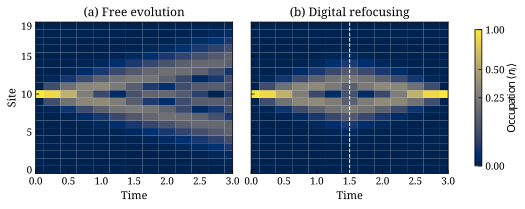

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["STIXGeneral"], "mathtext.fontset": "stix",
    "font.size": 10, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in", "svg.fonttype": "none",
    "legend.frameon": False,
})
occupation_norm = PowerNorm(gamma=0.5, vmin=0, vmax=1)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharex=True, sharey=True, layout="constrained")
for ax, occupation, title in zip(
    axes, [free_occupation, echo_occupation], ["(a) Free evolution", "(b) Digital refocusing"], strict=True,
):
    image = ax.pcolormesh(times, np.arange(length), occupation, shading="auto", cmap="cividis", norm=occupation_norm)
    ax.set(xlabel="Time", title=title, yticks=[0, 5, 10, 15, 19], xlim=(0, 3))
axes[0].set_ylabel("Site")
axes[1].axvline(half_duration, color="white", linestyle="--", linewidth=1)
fig.colorbar(image, ax=axes, label=r"Occupation $\langle n_i\rangle$", ticks=[0, 0.25, 0.5, 1], shrink=0.9)
plt.show()

**The phase pulse brings the spreading excitation back.** Both programs follow
the same dynamics until $t=1.5$. Free evolution continues to spread, while the
pulsed program refocuses at site 10 at $t=3$. The white dashed line marks the
midpoint pulse. Both panels use the same square-root color scale to retain weak
occupation without changing the normalization.

## 5. Add relaxation and dephasing

A pulse can reverse coherent spreading, but it cannot reverse an irreversible
noise process. Uniform relaxation removes the excitation. Local dephasing
preserves total excitation while disrupting the phases needed for refocusing.
Apply each noise model to the same echo program.

In [6]:
from mqt.yaqs import NoiseModel

relaxation_rate = 0.5
dephasing_rates = [0.05, 0.2]
noise_models = {
    "Relaxation": NoiseModel([
        {"name": "lowering", "sites": [site], "strength": relaxation_rate}
        for site in range(length)
    ]),
    **{
        f"Dephasing {rate:g}": NoiseModel([
            {"name": "pauli_z", "sites": [site], "strength": rate}
            for site in range(length)
        ])
        for rate in dephasing_rates
    },
}
echo_results = {"No noise": echo_result}
for label, noise in noise_models.items():
    echo_results[label] = simulator.run(state, echo_program, noise_model=noise)

occupations = {label: analog_occupations(result)[1] for label, result in echo_results.items()}

`strength` is a Lindblad rate in inverse time. The jump operators are
$\sqrt{\gamma_-}\,|0\rangle\langle1|_i$ for relaxation and
$\sqrt{\gamma_z}\,Z_i$ for dephasing. In this convention an isolated qubit's
off-diagonal density-matrix entries decay at rate $2\gamma_z$.

The run-level noise model is inherited by all segments. These one-qubit gates
receive no stochastic circuit noise in YAQS, so noise acts only during the
analog intervals here. The pulses are ideal and instantaneous. The same noisy
trajectory and random stream continue across the midpoint pulse.

For a single excitation with uniform relaxation, the exact total population is
$N(t)=\exp(-\gamma_-t)$. Surviving trajectories still refocus, so the exact
final return occupation has the same value, about $0.223$ at $t=3$. Under
Pauli-Z dephasing, $N(t)=1$, but the return becomes weaker and occupation
remains away from the center. This comparison uses different noise channels;
their numerical rates do not represent equal physical error strengths.

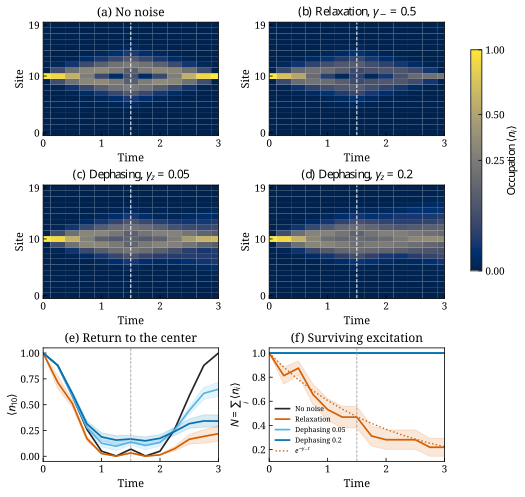

In [7]:
labels = list(echo_results)
colors = ["0.15", "#D55E00", "#56B4E9", "#0072B2"]
fig, axes = plt.subplots(3, 2, figsize=(7.2, 6.8), layout="constrained")
titles = ["(a) No noise", r"(b) Relaxation, $\gamma_-=0.5$",
          r"(c) Dephasing, $\gamma_z=0.05$", r"(d) Dephasing, $\gamma_z=0.2$"]
for ax, label, title in zip(axes[:2].flat, labels, titles, strict=True):
    image = ax.pcolormesh(times, np.arange(length), occupations[label], shading="auto", cmap="cividis", norm=occupation_norm)
    ax.axvline(half_duration, color="white", linestyle="--", linewidth=1)
    ax.set(xlabel="Time", ylabel="Site", title=title, yticks=[0, 10, 19], xlim=(0, 3))
fig.colorbar(image, ax=list(axes[:2].flat), label=r"Occupation $\langle n_i\rangle$",
             ticks=[0, 0.25, 0.5, 1], shrink=0.8)

for label, color in zip(labels, colors, strict=True):
    occupation = occupations[label]
    result = echo_results[label]
    segments = [segment for segment in result.segment_results if segment.segment_type == "analog"]
    raw_times = np.concatenate([segment.times + segment.time_offset for segment in segments])
    keep = np.r_[True, np.diff(raw_times) > 0]
    trajectories = (1 - np.concatenate([np.asarray(segment.trajectories) for segment in segments], axis=-1)) / 2
    trajectories = trajectories[..., keep]
    for ax, mean, samples in (
        (axes[2, 0], occupation[center], trajectories[center]),
        (axes[2, 1], occupation.sum(axis=0), trajectories.sum(axis=0)),
    ):
        ax.plot(times, mean, color=color, linewidth=1.7, label=label)
        if samples.shape[0] > 1:
            standard_error = samples.std(axis=0, ddof=1) / np.sqrt(samples.shape[0])
            ax.fill_between(times, mean - standard_error, mean + standard_error, color=color, alpha=0.15)
axes[2, 1].plot(times, np.exp(-relaxation_rate * times), ":", color="#D55E00", linewidth=1.4, label=r"$e^{-\gamma_-t}$")
for ax in axes[2]:
    ax.axvline(half_duration, color="0.6", linestyle="--", linewidth=0.8)
    ax.set(xlabel="Time", xlim=(0, 3))
axes[2, 0].set(title="(e) Return to the center", ylabel=r"$\langle n_{10}\rangle$")
axes[2, 1].set(title="(f) Surviving excitation", ylabel=r"$N=\sum_i\langle n_i\rangle$")
axes[2, 1].legend(fontsize=7, loc="lower left")
plt.show()

**Loss and dephasing limit the return in different ways.** Relaxation reduces
the total population, while the dephased excitation survives in a broader
spatial distribution. Increasing dephasing weakens the echo over the rates
shown. The lower panels separate the occupation returning to site 10 from the
total excitation remaining in the chain. Shading shows one standard error
estimated from complete trajectories; the dotted line gives the exact relaxation
envelope. These bands describe sampling uncertainty, not timestep or MPS
truncation error. Increase `num_traj` to reduce sampling fluctuations, and check
numerical convergence before interpreting small differences.

## Further options

Programs require an MPS initial state. Segment parameters control local timing,
accuracy, gate mode, and digital `shots`. Observables, `random_seed`, and
`get_state` belong on the program. A noiseless program can retain its final
state with `get_state=True`; noisy programs do not return a single final MPS. A
program-level `num_traj` overrides segment budgets. If omitted, all segment
budgets must agree. Digital segments can target qubits in a heterogeneous MPS;
non-qubit sites remain spectators. For analog-only Hamiltonian changes, use
`Hamiltonian.piecewise` as described in {doc}`hamiltonians`.

An optional third tuple entry overrides noise for one segment, for example
`(hamiltonian, analog_params, local_noise)`. `None` inherits run-level noise; an
empty `NoiseModel()` disables it for that segment. Digital operators may also be
OpenQASM strings or paths. Pass the pair list directly to `Simulator.run` with
program-wide keywords when a named program is unnecessary. The outer `counts`
contains the histogram from the last segment that sampled shots; inspect
`segment_results` for earlier histograms. Program execution does not support
`multi_time_observables`.

For deterministic scheduled jumps, see {ref}`noise-scheduled-jumps`. Jump times
use the analog run's local clock and must follow its `dt` grid with `order=1`.
Consecutive compatible analog segments share that clock; a digital gate starts a
new analog run. Use a segment noise override to attach a schedule to one
interval. For device-specific noise strengths and distributions, see
{doc}`realistic_noise_models`.